<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-lab/blob/main/lab_ch22_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 22: Clustering Economies — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** K-Means clustering, feature standardization, PCA visualization, silhouette evaluation, UMAP comparison, reusable Python modules.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install wbgapi scikit-learn matplotlib seaborn umap-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Load WDI data (shared setup for all parts)
# -----------------------------------------------------------

indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SP.DYN.IMRT.IN': 'infant_mortality',
    'SE.PRM.ENRR': 'primary_enrollment',
    'SI.POV.GINI': 'gini_index',
    'EN.ATM.CO2E.PC': 'co2_per_capita',
    'IT.NET.USER.ZS': 'internet_users_pct',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

# time=2022 used instead of mrv=1: most WDI indicators have a 2-4 year publication lag,
# so mrv=1 often returns all-null for the current year.
df = wb.data.DataFrame(list(indicators.keys()), time=2022, labels=True)
df = df.rename(columns=indicators)
df = df.dropna(thresh=7)
df = df.fillna(df.median(numeric_only=True))

# Only keep feature columns that are actually present (CO2 lags further than 2022)
feature_names = [name for name in indicators.values() if name in df.columns]

print(f'Countries retained: {len(df)}')
print(f'Features: {feature_names}')

Countries retained: 237
Features: ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']


---

## Part 1: DIAGNOSE — Find 4 Errors in This Clustering Pipeline

The code below attempts to cluster World Bank economies using K-Means.
There are **four deliberate errors** spread across four code cells:

1. A **preprocessing omission** error
2. An **API parameter** error
3. A **method ordering** error
4. A **reproducibility** error

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

In [3]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 1: Cluster raw (unstandardized) features
# -----------------------------------------------------------

# ERROR 1: Forgot to standardize before K-Means!
# GDP per capita ranges 300-120,000 while Gini ranges 25-65.
# Without StandardScaler, K-Means clusters almost entirely on GDP.

X_raw = df[feature_names].values  # Using RAW features — no scaling!

kmeans_bad = KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)
labels_bad = kmeans_bad.fit_predict(X_raw)

print('=== Clustering on RAW (unstandardized) features ===')
print(f'Cluster sizes: {np.bincount(labels_bad)}')
print()
for k in range(4):
    mask = labels_bad == k
    print(f'Cluster {k}: {mask.sum()} countries | '
          f'GDP/cap ${df.loc[mask, "gdp_per_capita_ppp"].mean():,.0f} | '
          f'Life Exp {df.loc[mask, "life_expectancy"].mean():.1f}')

print()
print('Notice: clusters are separated ONLY by GDP per capita.')
print('The other 9 features contribute almost nothing to the distance.')

=== Clustering on RAW (unstandardized) features ===
Cluster sizes: [ 39 138   5  55]

Cluster 0: 39 countries | GDP/cap $64,986 | Life Exp 81.1
Cluster 1: 138 countries | GDP/cap $9,390 | Life Exp 68.1
Cluster 2: 5 countries | GDP/cap $135,389 | Life Exp 82.5
Cluster 3: 55 countries | GDP/cap $32,330 | Life Exp 75.9

Notice: clusters are separated ONLY by GDP per capita.
The other 9 features contribute almost nothing to the distance.


In [4]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 2: Wrong argument name for n_clusters
# -----------------------------------------------------------

# ERROR 2: Using k=4 instead of n_clusters=4
# scikit-learn uses n_clusters, not k. This will raise a TypeError.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

try:
    kmeans_wrong = KMeans(k=4, init='k-means++', random_state=42)
    kmeans_wrong.fit(X_scaled)
except TypeError as e:
    print(f'ERROR: {e}')
    print()
    print('The correct parameter name is n_clusters, not k.')
    print('scikit-learn\'s KMeans uses: KMeans(n_clusters=4)')

ERROR: KMeans.__init__() got an unexpected keyword argument 'k'

The correct parameter name is n_clusters, not k.
scikit-learn's KMeans uses: KMeans(n_clusters=4)


In [5]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 3: PCA applied BEFORE standardization
# -----------------------------------------------------------

# ERROR 3: PCA is applied to raw data, then results are standardized.
# This is backwards! PCA should be applied AFTER standardization.
# PCA finds directions of maximum variance — on raw data, the first PC
# will be dominated by the highest-scale feature (GDP per capita).

# Wrong order: PCA first, then scale
pca_wrong = PCA(n_components=2)
X_pca_wrong = pca_wrong.fit_transform(df[feature_names].values)  # Raw data!
X_pca_then_scaled = StandardScaler().fit_transform(X_pca_wrong)  # Scaling after PCA

print('PCA on RAW data:')
print(f'  PC1 explains {pca_wrong.explained_variance_ratio_[0]:.1%} of variance')
print(f'  PC2 explains {pca_wrong.explained_variance_ratio_[1]:.1%} of variance')
print()
print('PC1 loading vector (top 3):')
loadings = pd.Series(pca_wrong.components_[0], index=feature_names)
top_loadings = loadings.abs().nlargest(3)
for feat in top_loadings.index:
    print(f'  {feat}: {loadings[feat]:.4f}')
print()
print('Notice: PC1 is almost entirely GDP per capita.')
print('Standardize FIRST, then apply PCA.')

PCA on RAW data:
  PC1 explains 100.0% of variance
  PC2 explains 0.0% of variance

PC1 loading vector (top 3):
  gdp_per_capita_ppp: 1.0000
  trade_pct_gdp: 0.0011
  internet_users_pct: 0.0006

Notice: PC1 is almost entirely GDP per capita.
Standardize FIRST, then apply PCA.


In [6]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 4: Missing random_state
# -----------------------------------------------------------

# ERROR 4: No random_state set — results change every time you run!
# K-Means uses random initialization. Without random_state,
# different runs may converge to different local minima.

X_scaled_ok = StandardScaler().fit_transform(df[feature_names])

# Run K-Means 3 times without random_state
results = []
for trial in range(3):
    km = KMeans(n_clusters=4, init='k-means++', n_init=1)  # No random_state!
    labels = km.fit_predict(X_scaled_ok)
    inertia = km.inertia_
    results.append((labels, inertia))
    print(f'Trial {trial+1}: WCSS = {inertia:.2f}, Cluster sizes = {np.bincount(labels)}')

# Check if results are identical
same_01 = np.array_equal(results[0][0], results[1][0])
same_12 = np.array_equal(results[1][0], results[2][0])
print(f'\nTrial 1 == Trial 2: {same_01}')
print(f'Trial 2 == Trial 3: {same_12}')
print()
if not (same_01 and same_12):
    print('Results differ across runs! Set random_state=42 for reproducibility.')
else:
    print('Results happened to match, but this is NOT guaranteed without random_state.')

Trial 1: WCSS = 1199.35, Cluster sizes = [32 69 93 43]
Trial 2: WCSS = 1189.49, Cluster sizes = [ 25  51 103  58]
Trial 3: WCSS = 1175.67, Cluster sizes = [107  54  57  19]

Trial 1 == Trial 2: False
Trial 2 == Trial 3: False

Results differ across runs! Set random_state=42 for reproducibility.


---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** clustering pipeline from scratch, fixing all four errors:

1. **Standardize** features with `StandardScaler` BEFORE clustering
2. **Use `n_clusters=4`**, not `k=4`
3. **Apply PCA AFTER standardization**, not before
4. **Set `random_state=42`** for reproducibility

**Verification checkpoints:**
- Standardized features should have mean ~ 0, std ~ 1
- PCA on standardized data: PC1 should explain 35-50% of variance (NOT 90%+)
- Silhouette score for K=4 should be between 0.15 and 0.40
- Cluster sizes should be roughly balanced (not 1 giant cluster + 3 tiny ones)

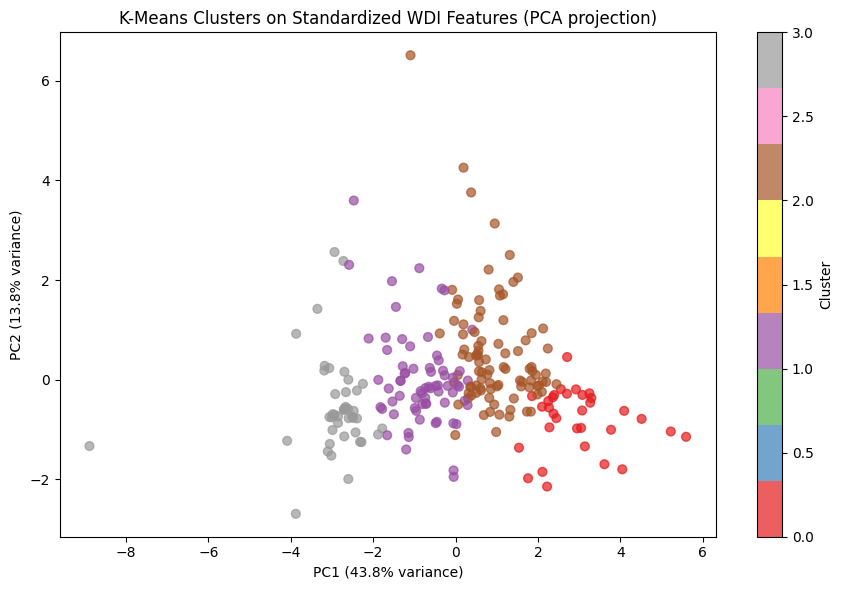

Standardized means: [ 0.  0. -0. -0.  0.  0.  0.  0. -0.]
PC1 variance explained: 43.8%
Silhouette score: 0.1639
Cluster sizes: [32 69 93 43]


In [7]:
# -----------------------------------------------------------
# YOUR TASK — Write the corrected clustering pipeline
# Fix all four errors from Part 1
# -----------------------------------------------------------

# Step 1: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

# Step 2: Fit K-Means with correct parameter name and random_state
kmeans = KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Step 3: Apply PCA to STANDARDIZED data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Visualize — PCA scatter plot colored by cluster
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set1', alpha=0.7, s=40)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('K-Means Clusters on Standardized WDI Features (PCA projection)')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

# VERIFICATION
print(f'Standardized means: {X_scaled.mean(axis=0).round(4)}')
print(f'PC1 variance explained: {pca.explained_variance_ratio_[0]:.1%}')
print(f'Silhouette score: {silhouette_score(X_scaled, labels):.4f}')
print(f'Cluster sizes: {np.bincount(labels)}')

---

## Part 3: EXTEND — Customer Segmentation with Synthetic Data

Move beyond country-level data. In this section, you apply clustering to
a **customer segmentation** problem using synthetic behavioral data.
This mirrors how fintechs like Nubank (Chapter 22 opening hook) discover
customer archetypes from transaction patterns.

Then compare **PCA** and **UMAP** for dimensionality reduction.

In [8]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Generate synthetic customer data with 4 latent segments
# -----------------------------------------------------------

from sklearn.datasets import make_blobs

np.random.seed(42)

# Create 4 customer segments with 6 behavioral features
n_customers = 2000
segment_centers = [
    [50, 5, 80, 10, 2, 30],    # Budget-conscious: low spend, few txns, high app usage
    [200, 20, 40, 50, 8, 70],   # Power users: high spend, many txns
    [120, 12, 60, 30, 5, 50],   # Moderate users
    [300, 30, 20, 80, 12, 90],  # Premium: very high spend, low app engagement
]

X_cust, y_true = make_blobs(
    n_samples=n_customers,
    centers=segment_centers,
    cluster_std=[15, 25, 20, 20],
    random_state=42
)

cust_features = [
    'avg_monthly_spend', 'txn_frequency', 'app_sessions',
    'credit_utilization', 'products_held', 'digital_engagement'
]

cust_df = pd.DataFrame(X_cust, columns=cust_features)
cust_df['true_segment'] = y_true

print(f'Customers: {len(cust_df)}')
print(f'Features: {cust_features}')
print(f'True segments: {cust_df["true_segment"].value_counts().sort_index().to_dict()}')
print()
print(cust_df[cust_features].describe().round(1))

Customers: 2000
Features: ['avg_monthly_spend', 'txn_frequency', 'app_sessions', 'credit_utilization', 'products_held', 'digital_engagement']
True segments: {0: 500, 1: 500, 2: 500, 3: 500}

       avg_monthly_spend  txn_frequency  app_sessions  credit_utilization  \
count             2000.0         2000.0        2000.0              2000.0   
mean               167.4           16.7          50.2                41.7   
std                 94.6           22.2          30.4                33.0   
min                 10.5          -51.4         -58.4               -43.8   
25%                 80.3            1.1          26.9                15.4   
50%                155.2           15.7          52.3                38.8   
75%                251.2           31.5          74.8                67.0   
max                355.4           91.7         123.2               138.3   

       products_held  digital_engagement  
count         2000.0              2000.0  
mean             6.1         

In [ ]:
# -----------------------------------------------------------
# YOUR TASK — Cluster customers and compare PCA vs UMAP
# -----------------------------------------------------------

import umap

# Step 1: Standardize customer features
cust_scaler = StandardScaler()
X_cust_scaled = cust_scaler.fit_transform(cust_df[cust_features])

# Step 2: Fit K-Means with K=4 (we know the true number here)
km_cust = KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)
cust_df['kmeans_cluster'] = km_cust.fit_predict(X_cust_scaled)

# Step 3: PCA projection
pca_cust = PCA(n_components=2)
X_pca_cust = pca_cust.fit_transform(X_cust_scaled)

# Step 4: UMAP projection
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)
X_umap_cust = reducer.fit_transform(X_cust_scaled)

# Step 5: Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter1 = axes[0].scatter(X_pca_cust[:, 0], X_pca_cust[:, 1],
                           c=cust_df['true_segment'], cmap='Set1',
                           alpha=0.5, s=15)
axes[0].set_title('PCA — True Segments', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

scatter2 = axes[1].scatter(X_pca_cust[:, 0], X_pca_cust[:, 1],
                           c=cust_df['kmeans_cluster'], cmap='Set1',
                           alpha=0.5, s=15)
axes[1].set_title('PCA — K-Means Clusters', fontsize=12)
axes[1].set_xlabel('PC1')

scatter3 = axes[2].scatter(X_umap_cust[:, 0], X_umap_cust[:, 1],
                           c=cust_df['kmeans_cluster'], cmap='Set1',
                           alpha=0.5, s=15)
axes[2].set_title('UMAP — K-Means Clusters', fontsize=12)
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

sil_kmeans = silhouette_score(X_cust_scaled, cust_df['kmeans_cluster'])
print(f'Silhouette score (K-Means K=4): {sil_kmeans:.4f}')
print()
print('Compare PCA vs UMAP: Which gives better visual separation?')
print('UMAP preserves local structure better than PCA for non-linear data.')

---

## Part 4: Module Output — `clustering_utils.py`

Write a reusable Python module with three functions for clustering pipelines.
This is a **portfolio artifact** that demonstrates production-grade unsupervised learning.

### Requirements

```python
# clustering_utils.py

def run_kmeans_pipeline(df, features, k, random_state=42):
    """End-to-end K-Means pipeline: standardize, fit, return labels + metadata."""
    ...

def evaluate_k_range(X, k_range, random_state=42):
    """Compute WCSS and silhouette scores for a range of K values."""
    ...

def plot_pca_clusters(X, labels, feature_names):
    """PCA 2D scatter with cluster coloring + loadings annotation."""
    ...
```

In [ ]:
%%writefile clustering_utils.py
"""
clustering_utils.py — Reusable Clustering Pipeline Module

Functions for standardized K-Means clustering, K evaluation,
and PCA visualization.

Author: Wanchen Lang
Course: ECON 5200, Lab 22
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from typing import List, Dict


def run_kmeans_pipeline(
    df: pd.DataFrame,
    features: List[str],
    k: int,
    random_state: int = 42
) -> Dict:
    """End-to-end K-Means pipeline: standardize, fit, return labels + metadata."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])

    model = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=random_state)
    labels = model.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels) if k > 1 else float('nan')

    return {
        'labels': labels,
        'scaler': scaler,
        'model': model,
        'X_scaled': X_scaled,
        'silhouette': sil,
        'inertia': model.inertia_,
    }


def evaluate_k_range(
    X: np.ndarray,
    k_range: range,
    random_state: int = 42
) -> pd.DataFrame:
    """Compute WCSS and silhouette scores for a range of K values."""
    records = []
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=random_state)
        labels = km.fit_predict(X)
        sil = silhouette_score(X, labels) if k > 1 else float('nan')
        records.append({'k': k, 'wcss': km.inertia_, 'silhouette': sil})
    return pd.DataFrame(records)


def plot_pca_clusters(
    X: np.ndarray,
    labels: np.ndarray,
    feature_names: List[str]
) -> None:
    """PCA 2D scatter with cluster coloring + loadings annotation."""
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    fig, ax = plt.subplots(figsize=(9, 7))
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='Set1', alpha=0.7, s=30)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
    ax.set_title('K-Means Clusters (PCA projection)')
    plt.colorbar(scatter, ax=ax, label='Cluster')

    # Loadings annotation: draw arrows for top-3 features by PC1 loading magnitude
    loadings = pca.components_.T  # shape (n_features, 2)
    scale = np.abs(X_2d).max() * 0.45
    top_idx = np.argsort(np.abs(loadings[:, 0]))[-3:]
    for i in top_idx:
        ax.annotate(
            '', xy=(loadings[i, 0] * scale, loadings[i, 1] * scale),
            xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5)
        )
        ax.text(
            loadings[i, 0] * scale * 1.12,
            loadings[i, 1] * scale * 1.12,
            feature_names[i],
            fontsize=8, ha='center', color='black'
        )

    plt.tight_layout()
    plt.show()


# --- Quick self-test ---
if __name__ == '__main__':
    from sklearn.datasets import make_blobs
    X_test, _ = make_blobs(n_samples=200, centers=3, n_features=5, random_state=0)
    df_test = pd.DataFrame(X_test, columns=[f'f{i}' for i in range(5)])

    result = run_kmeans_pipeline(df_test, [f'f{i}' for i in range(5)], k=3)
    print(f'Labels shape: {result["labels"].shape}')
    print(f'Silhouette: {result["silhouette"]:.4f}')

    eval_df = evaluate_k_range(result['X_scaled'], range(2, 8))
    print(eval_df)

    plot_pca_clusters(result['X_scaled'], result['labels'], [f'f{i}' for i in range(5)])
    print('Self-test passed.')

---

## Challenge: Hierarchical Clustering Comparison

K-Means assumes spherical clusters and requires you to specify K upfront.
**Agglomerative hierarchical clustering** builds a tree (dendrogram) of
nested clusters and lets you choose K after inspecting the tree.

Compare K-Means and Agglomerative clustering on the WDI data:
1. Fit `AgglomerativeClustering(n_clusters=4)` on the standardized WDI data
2. Plot the dendrogram using `scipy.cluster.hierarchy`
3. Compare cluster assignments with K-Means — do they agree?

In [ ]:
# -----------------------------------------------------------
# CHALLENGE — Hierarchical clustering + dendrogram
# -----------------------------------------------------------

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Reuse the standardized WDI data from Part 2
# X_scaled and labels are already defined above

# Step 1: Fit agglomerative clustering
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

# Step 2: Plot dendrogram
fig, ax = plt.subplots(figsize=(12, 5))
linkage_matrix = linkage(X_scaled, method='ward')
dendrogram(linkage_matrix, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=9, ax=ax)
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage, WDI data)')
ax.set_xlabel('Country cluster (truncated)')
ax.set_ylabel('Ward distance')
plt.tight_layout()
plt.show()

# Step 3: Cross-tabulate K-Means vs Agglomerative labels
cross_tab = pd.crosstab(labels, agg_labels,
                        rownames=['K-Means cluster'],
                        colnames=['Agglomerative cluster'])
print('Cross-tabulation of K-Means vs Agglomerative assignments:')
print(cross_tab)
print()

# Step 4: Compare silhouette scores
sil_kmeans = silhouette_score(X_scaled, labels)
sil_agg    = silhouette_score(X_scaled, agg_labels)
print(f'Silhouette — K-Means:        {sil_kmeans:.4f}')
print(f'Silhouette — Agglomerative:  {sil_agg:.4f}')
print()
print('Interpretation: higher silhouette = tighter, better-separated clusters.')
print('Agglomerative (Ward) often matches K-Means closely on low-dimensional data.')

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken K-Means pipeline (missing standardization,
  wrong parameter name, PCA before scaling, no random_state)
* Built a corrected pipeline: StandardScaler -> K-Means -> PCA visualization
* Applied clustering to customer segmentation with synthetic behavioral data
* Compared PCA vs UMAP for dimensionality reduction
* Built a reusable clustering_utils.py module with run_kmeans_pipeline(),
  evaluate_k_range(), and plot_pca_clusters()
* Key finding: [FILL IN — what K was optimal? How did PCA vs UMAP compare?]

**Please write a README.md entry including:**
1. Project Title: Unsupervised Learning — Clustering & Dimensionality Reduction
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-22-clustering
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 22: Clustering Economies — K-Means, PCA, UMAP & Module"
git push origin main
```

Submit your GitHub repo link on Canvas.